In [ ]:
from Utils.import_packages import *

import swifter
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.model_selection import GridSearchCV

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

import string


# Download NLTK data
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
# nltk.download('punkt_tab')
# nltk.download('averaged_perceptron_tagger_eng')

nltk.download('stopwords')
nltk.download('wordnet')

warnings.filterwarnings('ignore')


In [ ]:
train = pd.read_csv('Data/train_labelled.csv')
val = pd.read_csv('Data/val_labelled.csv')
test = pd.read_csv('Data/test_labelled.csv')

# Naive Bayes


In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN
    
# Preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    
    # Tokenize text
    tokens = word_tokenize(text.lower(), language='english')
    
    # Get POS tags
    pos_tags = pos_tag(tokens)

    # Remove punctuation and stopwords, and lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tags 
              if word not in stop_words and word not in string.punctuation]
    return ' '.join(tokens)

def text_to_vector(df, vectorise_columns, numerical_columns = []):
    vectorizer = CountVectorizer()
    ret_df = pd.DataFrame()
    all_col = vectorise_columns + numerical_columns
    for col in all_col:
        if col in vectorise_columns:
            vectorized = vectorizer.fit_transform(df[col])
            ret_df = pd.concat([ret_df, pd.DataFrame(vectorized.toarray())], axis=1)
        else:
            ret_df[col] = df[col]
    return ret_df


In [ ]:

train['processed_title'] = train['title'].swifter.apply(preprocess_text)
val['processed_title'] = val['title'].swifter.apply(preprocess_text)

# Prepare data for Naive Bayes
X_train = train['processed_title']
y_train  = train['sentiment_label']

X_val = val['processed_title']
y_val  = val['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)
X_val_vectorized = vectorizer.transform(X_val)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = nb.predict(X_val_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Pandas Apply:   0%|          | 0/187160 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/60169 [00:00<?, ?it/s]

Accuracy: 0.5118084063221925
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.37      0.42     29334
           1       0.52      0.65      0.58     30835

    accuracy                           0.51     60169
   macro avg       0.51      0.51      0.50     60169
weighted avg       0.51      0.51      0.50     60169



In [ ]:
preds_NB = nb.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_NB = auc(fpr, tpr)
roc_auc_NB

0.5143386062319065

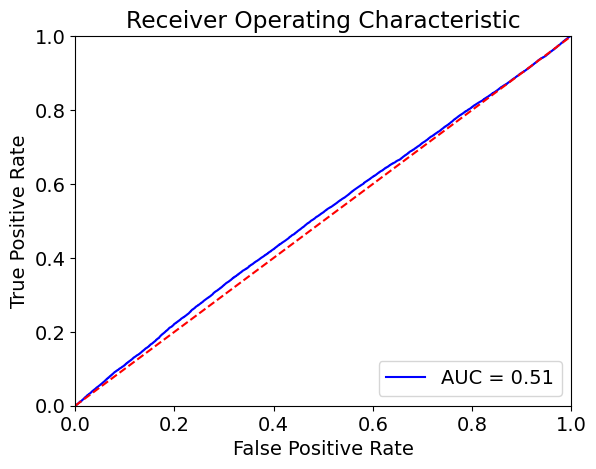

In [ ]:
import matplotlib.pyplot as plt
plt.rc("font", size=14)
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc_NB)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:

test['processed_title'] = test['title'].swifter.apply(preprocess_text)
train_val = pd.concat([train, val])

# Prepare data for Naive Bayes
X_train_val = train_val['processed_title']
y_train_val  = train_val['sentiment_label']

X_test = test['processed_title']
y_test  = test['sentiment_label']

# Convert text to numerical features using CountVectorizer
vectorizer = CountVectorizer()
X_train_val_vectorized = vectorizer.fit_transform(X_train_val)
X_test_vectorized = vectorizer.transform(X_test)

# Train a Naive Bayes classifier
nb = MultinomialNB()
nb.fit(X_train_val_vectorized, y_train_val)

# Make predictions
y_pred = nb.predict(X_test_vectorized)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Pandas Apply:   0%|          | 0/23239 [00:00<?, ?it/s]

Accuracy: 0.5052713111579672
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.41      0.46     11976
           1       0.49      0.60      0.54     11263

    accuracy                           0.51     23239
   macro avg       0.51      0.51      0.50     23239
weighted avg       0.51      0.51      0.50     23239



# Logistic Regression

In [ ]:
param_grid = {'C': [0.01, 0.1, 0.5], 'solver': ['lbfgs', 'liblinear']}
logreg = LogisticRegression(solver = 'lbfgs', penalty = 'l2', C = 0.1, warm_start=True, random_state=2024)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="f1")
grid_search.fit(X_train_vectorized, y_train)

logreg = LogisticRegression(**grid_search.best_params_, warm_start=True, random_state=2024)
logreg.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = logreg.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

Accuracy: 0.5138526483737473
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.33      0.40     29334
           1       0.52      0.69      0.59     30835

    accuracy                           0.51     60169
   macro avg       0.51      0.51      0.50     60169
weighted avg       0.51      0.51      0.50     60169



In [ ]:
preds_lr = logreg.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_lr = auc(fpr, tpr)
roc_auc_lr

0.5143386062319065

# RandomForest Classifier

In [ ]:
rf = RandomForestClassifier(random_state=2024) 
rf.fit(X_train_vectorized, y_train)

# Make predictions
y_pred_val = rf.predict(X_val_vectorized)
# Evaluate the model
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print("Classification Report:\n", classification_report(y_val, y_pred_val))

In [ ]:
preds_rf = rf.predict_proba(X_val_vectorized)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, preds_NB)  
roc_auc_rf = auc(fpr, tpr)
roc_auc_rf

0        agilent technology inc. present bio partner jp...
1        agilent technology inc. present j.p. morgan 42...
2        agilent technology inc. announce new proteoana...
3        agilent technology inc. present 23rd annual pe...
4                     agilent technology inc. special call
                               ...                        
43093    zoetis inc. declare fourth quarter 2024 divide...
43094    zoetis gear report q3 earnings 's offing yahoo...
43095    phibro animal health corporation nasdaqgm pahc...
43096          zoetis inc. 0.432 cash dividend oct-31-2024
43097    phibro animal health corporation complete acqu...
Name: processed_title, Length: 43098, dtype: object